## First tests of postprocessing from PA2 results

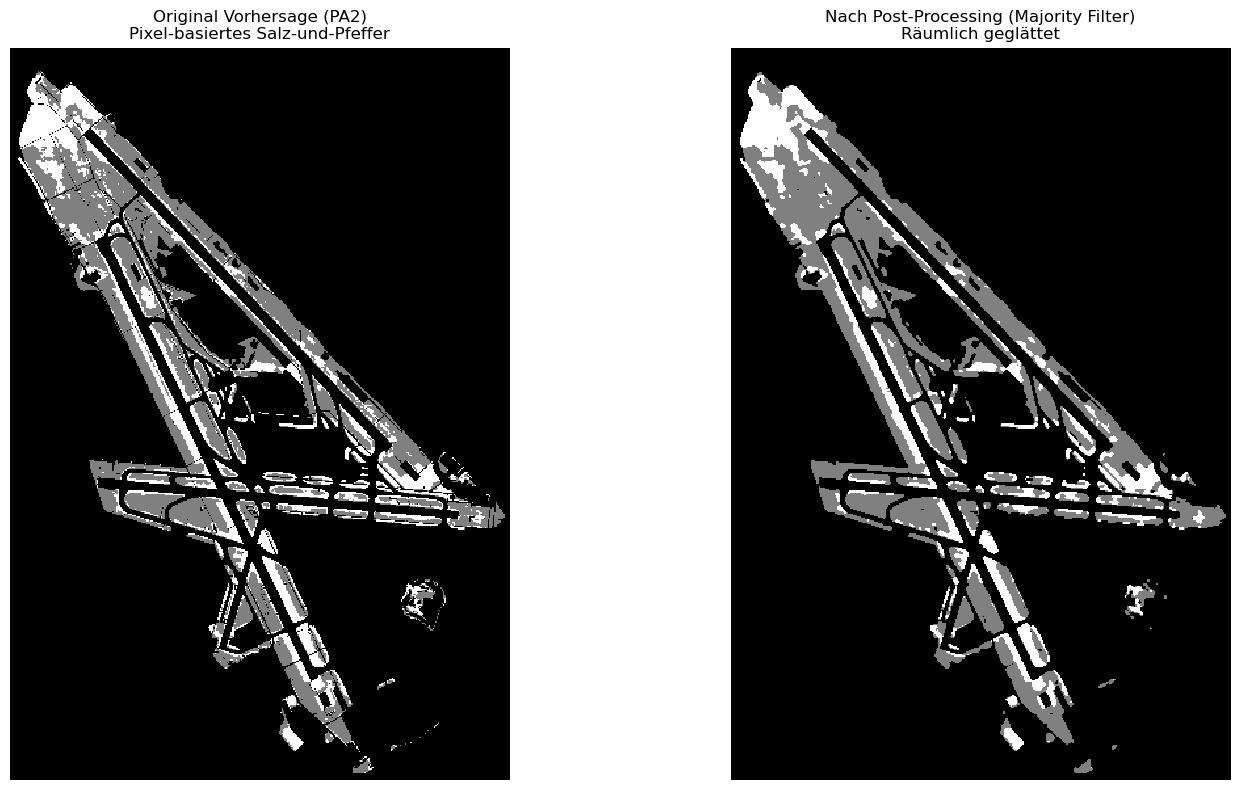

Als 'gemäht' klassifizierte Pixel (Vorher):  12473
Als 'gemäht' klassifizierte Pixel (Nachher): 10411
Differenz (Herausgefiltertes Rauschen):      2062


In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# 1. Pfad zu deiner alten PA2-Prediction Map anpassen
# (Passe den Pfad an, je nachdem wo dein BA-Ordner im Verhältnis zum PA2-Ordner liegt)
file_path = "C:/Workspace/ZHAW/5_Semester/airport-mowing-detection/docs/images/pred_map_2020-08-12_tuned_svm_hybrid.tif"

# 2. Die TIF-Datei laden
with rasterio.open(file_path) as src:
    # Wir laden das erste Band. Es enthält deine 0 (nicht gemäht) und 1 (gemäht)
    pred_map = src.read(1)
    
    # Optional: NoData-Werte (z.B. Ränder) ignorieren, falls vorhanden
    # Wir setzen sie vorübergehend auf 0, damit der Filter nicht abstürzt
    pred_map = np.nan_to_num(pred_map, nan=0)

# 3. Das Post-Processing (Majority Vote)
# size=3 bedeutet ein 3x3 Pixel Fenster (9 Pixel insgesamt)
# size=5 wäre ein 5x5 Fenster (stärkere Glättung)
filtered_map = median_filter(pred_map, size=3)

# 4. Vorher-Nachher Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Wir nutzen cmap='gray': 0 = schwarz (nicht gemäht), 1 = weiss (gemäht)
axes[0].imshow(pred_map, cmap='gray', interpolation='none')
axes[0].set_title('Original Vorhersage (PA2)\nPixel-basiertes Salz-und-Pfeffer')
axes[0].axis('off')

axes[1].imshow(filtered_map, cmap='gray', interpolation='none')
axes[1].set_title('Nach Post-Processing (Majority Filter)\nRäumlich geglättet')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 5. Kurze Statistik zur Überprüfung
pixel_vorher = np.sum(pred_map == 1)
pixel_nachher = np.sum(filtered_map == 1)
print(f"Als 'gemäht' klassifizierte Pixel (Vorher):  {pixel_vorher}")
print(f"Als 'gemäht' klassifizierte Pixel (Nachher): {pixel_nachher}")
print(f"Differenz (Herausgefiltertes Rauschen):      {pixel_vorher - pixel_nachher}")